# Notebook 3: EDA - ML Models - RAG Pipeline - Evaluation - Gradio UI
**Fridge Hero -- BT5153 Group 9**

**Run order: NB1 -> NB2 -> NB3**

## What this notebook does

**Part 1 — EDA**
Visualise rating distribution, cook time, calories, tags, interactions per user.
Insight: 71% of users rated only 1 recipe (long-tail) → need cold-start fallback.

**Part 2 — K-Means (Unsupervised)**
Cluster 180,310 users by cooking behaviour (8 interaction-based features).
Used as cold-start fallback: low-confidence users inherit cluster-average preferences.

**Part 3 — NCF (Supervised)**
Neural Collaborative Filtering: predict user-recipe rating from interaction history.
Architecture: Embedding(user) + Embedding(recipe) -> MLP -> rating.
Early stopping (patience=3). Test RMSE: 1.2759.

**Part 4 — RAG Pipeline**
ingredient index (exact overlap) -> ChromaDB (semantic) -> hybrid score (6 components).
Cook Now: filter must_buy==0 -> 3 recipes cookable immediately.
Pantry utilisation: 1.000 (after substitution + filter).

**Part 5 — Evaluation**
NCF metrics, pantry utilisation, LLM-as-judge (50 users), RAGAS.

**Part 6 — Gradio UI**
2 tabs: Customer Profile + Cook Now (3 recipes, no shopping required).

In [1]:
import pandas as pd
import numpy as np
import json, ast, re, os, pickle, warnings
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import Counter
from sentence_transformers import SentenceTransformer
import chromadb
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import gradio as gr
from ragas import evaluate
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from ragas.metrics import Faithfulness, AnswerRelevancy, ContextPrecision
from ragas.run_config import RunConfig
from langchain_community.llms import Ollama
from langchain_community.chat_models import ChatOllama   
from langchain_community.embeddings import OllamaEmbeddings
from langchain_community.llms import Ollama as LangchainOllama
from datasets import Dataset as HFDataset
from sklearn.cluster import KMeans, MiniBatchKMeans
import profile
import scipy.sparse as sp


warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

DATA_DIR   = './data/'
OUT_DIR    = './output/'
CHROMA_DIR = './chromadb/'
OLLAMA_URL   = 'http://localhost:11434/api/generate'
OLLAMA_MODEL = 'qwen2.5:7b'
SBERT_MODEL  = 'all-MiniLM-L6-v2'

os.makedirs(OUT_DIR, exist_ok=True)

# Load full interactions for EDA only (not used for train/eval)
interact = pd.read_csv(DATA_DIR + 'RAW_interactions.csv')


    
print('Setup complete.')

C:\Users\New\AppData\Local\Temp\ipykernel_41584\2455805186.py:22: DeprecationWarning: Importing Faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import Faithfulness
  from ragas.metrics import Faithfulness, AnswerRelevancy, ContextPrecision
C:\Users\New\AppData\Local\Temp\ipykernel_41584\2455805186.py:22: DeprecationWarning: Importing AnswerRelevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import AnswerRelevancy
  from ragas.metrics import Faithfulness, AnswerRelevancy, ContextPrecision
C:\Users\New\AppData\Local\Temp\ipykernel_41584\2455805186.py:22: DeprecationWarning: Importing ContextPrecision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import ContextP

Setup complete.


In [2]:
# Check Ollama is running before proceeding
try:
    r = requests.get('http://localhost:11434/api/tags', timeout=5)
    print('Ollama running:', [m['name'] for m in r.json().get('models', [])])
except:
    print('Ollama NOT running — start with: ollama serve')

Ollama running: ['qwen2.5:7b', 'llama3.2:latest', 'nomic-embed-text:latest', 'qwen3:4b', 'qwen2.5:3b', 'gpt-oss:120b-cloud']


In [3]:
# Verify Ollama model is available
try:
    r = requests.post('http://localhost:11434/api/pull',
                      json={'name': OLLAMA_MODEL}, stream=True)
    for line in r.iter_lines():
        if line:
            status = json.loads(line.decode('utf-8')).get('status', '')
            if status:
                print(status)
    print(f'Model {OLLAMA_MODEL} ready.')
except Exception as e:
    print(f'Ollama pull failed: {e}')

pulling manifest
pulling 2bada8a74506
pulling 66b9ea09bd5b
pulling eb4402837c78
pulling 832dd9e00a68
pulling 2f15b3218f05
verifying sha256 digest
writing manifest
success
Model qwen2.5:7b ready.


---
# Part 1 — EDA
Visualise dataset distributions to inform design decisions.

In [4]:
recipes  = pd.read_csv(OUT_DIR + 'recipe_clean.csv')
profiles = pd.read_csv(OUT_DIR + 'user_profile_enriched.csv')
print(f'Recipes : {len(recipes):,}')
print(f'Users   : {len(profiles):,}')
print(f'Reviews : {len(interact):,}')

Recipes : 225,044
Users   : 180,310
Reviews : 1,132,367


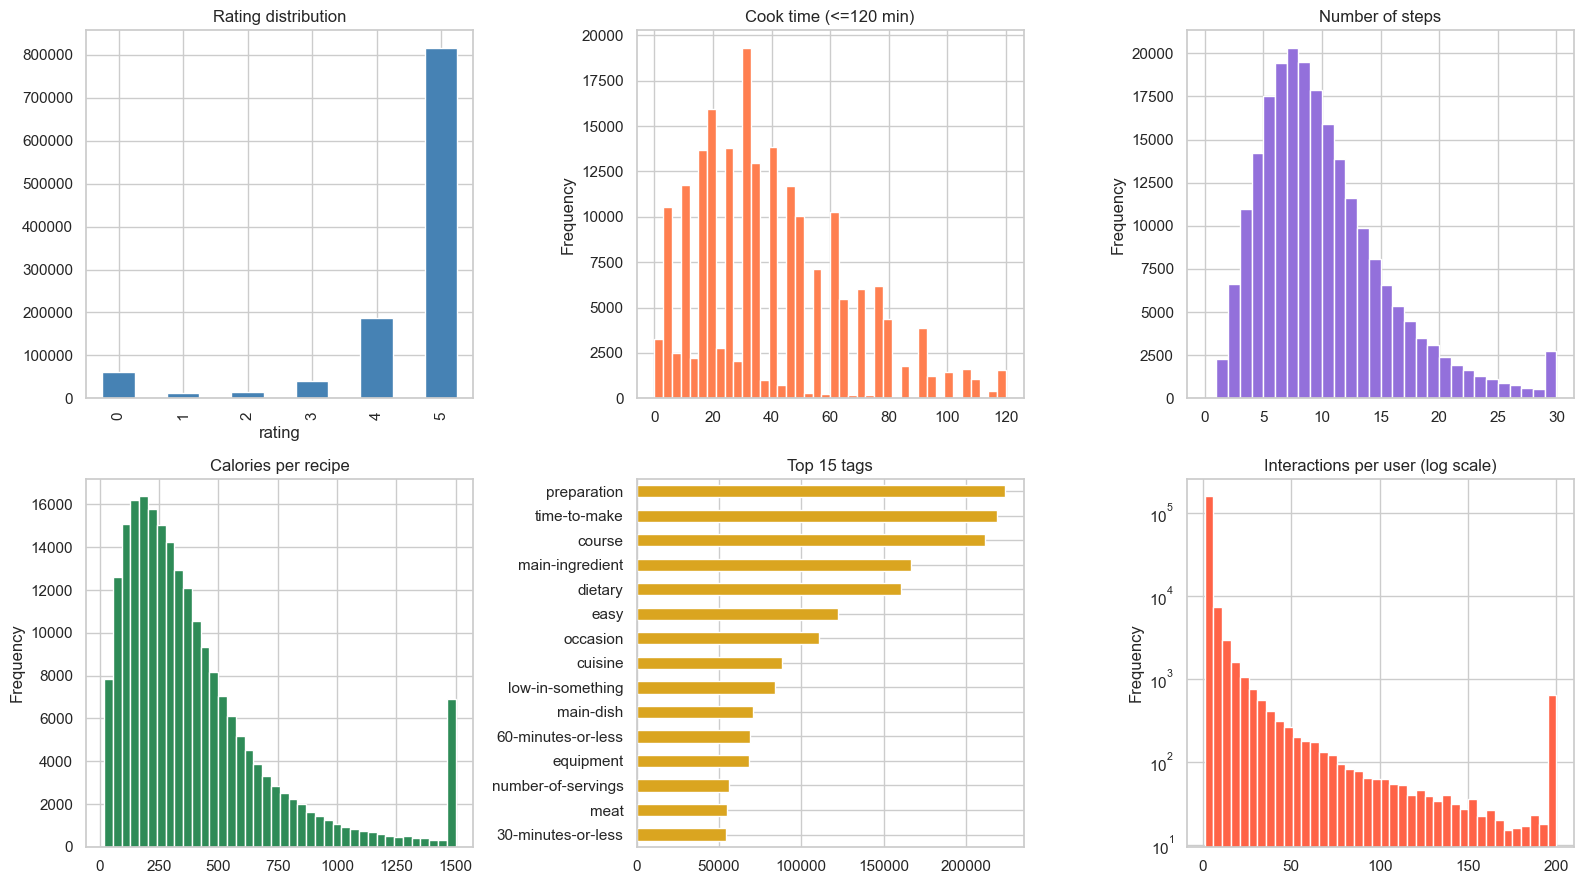

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

interact['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Rating distribution')

recipes[recipes['minutes'] <= 120]['minutes'].plot(
    kind='hist', bins=40, ax=axes[0,1], color='coral')
axes[0,1].set_title('Cook time (<=120 min)')

recipes['n_steps'].clip(upper=30).plot(
    kind='hist', bins=30, ax=axes[0,2], color='mediumpurple')
axes[0,2].set_title('Number of steps')

recipes['calories'].clip(upper=1500).plot(
    kind='hist', bins=40, ax=axes[1,0], color='seagreen')
axes[1,0].set_title('Calories per recipe')

all_tags = []
for t in recipes['tags_str'].dropna():
    all_tags.extend(t.split(', '))
pd.Series(Counter(all_tags)).sort_values(ascending=False).head(15).plot(
    kind='barh', ax=axes[1,1], color='goldenrod')
axes[1,1].set_title('Top 15 tags')
axes[1,1].invert_yaxis()

profiles['n_recipes_rated'].clip(upper=200).plot(
    kind='hist', bins=40, ax=axes[1,2], color='tomato', log=True)
axes[1,2].set_title('Interactions per user (log scale)')

plt.tight_layout()
plt.savefig(OUT_DIR + 'eda_overview.png', dpi=150)
plt.show()

In [6]:
print('=== Enriched Profile Summary ===')
print(f"avoids_meat : {profiles['avoids_meat'].sum():,} users")
print()
print('spicy_preference:')
print(profiles['spicy_preference'].value_counts())
print()
print(profiles[['avg_minutes','avg_calories','avg_protein_pdv','vegetarian_ratio']].describe().round(2))

=== Enriched Profile Summary ===
avoids_meat : 0 users

spicy_preference:
spicy_preference
medium    180185
low          123
high           2
Name: count, dtype: int64

        avg_minutes  avg_calories  avg_protein_pdv  vegetarian_ratio
count  1.803100e+05     180310.00        180310.00         180310.00
mean   1.757356e+04        500.37            38.55              0.14
std    5.340665e+06        790.01            84.00              0.31
min    0.000000e+00          0.00             0.00              0.00
25%    3.000000e+01        219.30             9.00              0.00
50%    5.000000e+01        360.80            26.00              0.00
75%    8.000000e+01        555.10            52.75              0.00
max    2.147484e+09     101614.70          6552.00              1.00


---
# Part 2 -- ML Model A: K-Means User Clustering (Unsupervised)

Groups users by cooking behaviour for two purposes:
1. **Segmentation analysis** -- understand user types (e.g. vegetarian cluster, quick-cook cluster)
2. **Cold-start fallback** -- low-confidence users inherit cluster-average preferences in get_user_profile()

**Features (8, all from interaction history -- no LLM):**
avg_minutes (hard-capped 1440, winsorized 95th pct, log-transformed),
avg_calories (hard-capped 10000, winsorized, log-transformed),
avg_protein_pdv, avg_fat_pdv, avg_carbs_pdv, avg_n_steps, vegetarian_ratio, avg_rating_given

Note: spicy_num and avoids_meat_num removed -- these come from LLM inference (only 200/180k users have real values).
Best K selected by silhouette score.

In [7]:
def spicy_to_num(s):
    return {'low': 0, 'medium': 1, 'high': 2}.get(str(s), 1)

cluster_features = profiles[[
    'avg_minutes', 'avg_calories', 'avg_protein_pdv',
    'avg_fat_pdv', 'avg_carbs_pdv', 'avg_n_steps',
    'vegetarian_ratio', 'avg_rating_given'
]].copy()
# spicy_num and avoids_meat_num removed — these come from LLM inference (only 200 users)
# K-Means uses only interaction-derived features (all 180,310 users)
cluster_features = cluster_features.fillna(cluster_features.median())

# Winsorize avg_minutes and avg_calories at 99th percentile
# Raw max: avg_minutes=2.1B, avg_calories=101,614 — extreme outliers break K-Means
# Hard cap first — remove corrupted/impossible values
# avg_minutes max = 2,147,483,647 (Integer max, corrupted data)
cluster_features['avg_minutes']  = cluster_features['avg_minutes'].clip(upper=1440)   # max 24h
cluster_features['avg_calories'] = cluster_features['avg_calories'].clip(upper=10000) # max reasonable

# Winsorize at 95th percentile after hard cap
for col in ['avg_minutes', 'avg_calories']:
    cap = cluster_features[col].quantile(0.95)
    cluster_features[col] = cluster_features[col].clip(upper=cap)
    print(f'Winsorized {col}: capped at {cap:.1f}')

# Log-transform to reduce skewness before standardizing
for col in ['avg_minutes', 'avg_calories']:
    cluster_features[col] = np.log1p(cluster_features[col])

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(cluster_features)
print('Feature matrix shape:', X_scaled.shape)

Winsorized avg_minutes: capped at 291.6
Winsorized avg_calories: capped at 1263.5
Feature matrix shape: (180310, 8)


Finding optimal K: 100%|██████████| 9/9 [00:10<00:00,  1.12s/it]


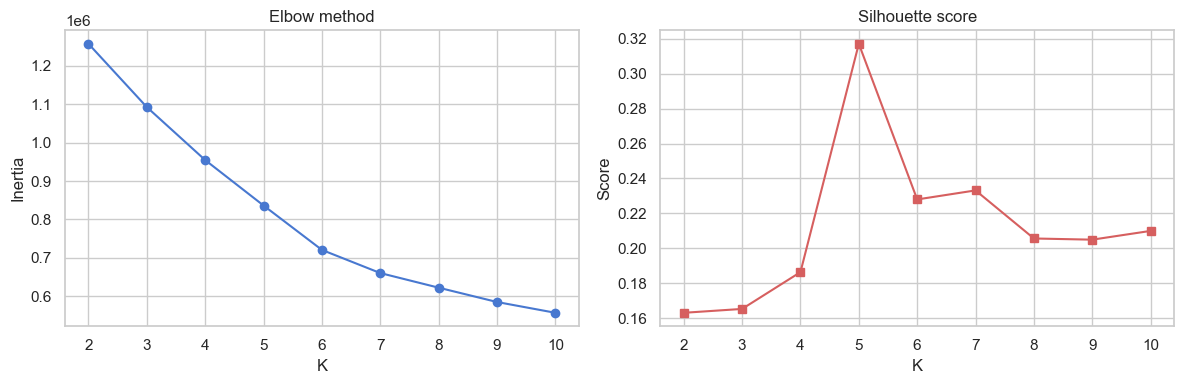

Best K by silhouette: 5


In [8]:
inertias   = []
sil_scores = []
K_range    = range(2, 11)

for k in tqdm(K_range, desc='Finding optimal K'):
    km  = KMeans(n_clusters=k, random_state=42, n_init=3)
    lbl = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    if len(set(lbl)) > 1:
        sil_scores.append(silhouette_score(X_scaled, lbl, sample_size=5000, random_state=42))
    else:
        sil_scores.append(-1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(K_range, inertias, 'bo-')
ax1.set_title('Elbow method'); ax1.set_xlabel('K'); ax1.set_ylabel('Inertia')
ax2.plot(K_range, sil_scores, 'rs-')
ax2.set_title('Silhouette score'); ax2.set_xlabel('K'); ax2.set_ylabel('Score')
plt.tight_layout()
plt.savefig(OUT_DIR + 'kmeans_elbow.png', dpi=150)
plt.show()

BEST_K = list(K_range)[np.argmax(sil_scores)]
print(f'Best K by silhouette: {BEST_K}')

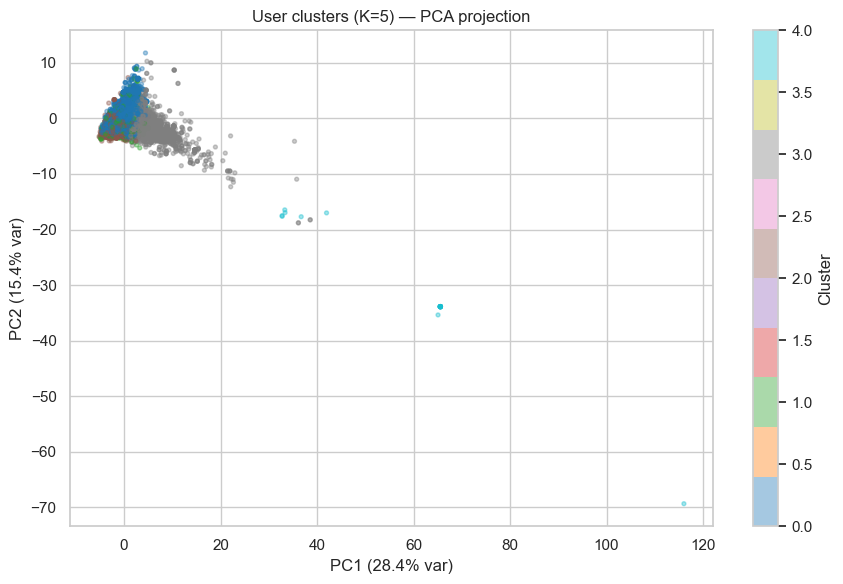

,n_users,avg_minutes,avg_calories,vegetarian_ratio,spicy_high_pct
cluster,,,,,
0,129279,18578.69,427.88,0.03,0.0
1,23935,30026.58,425.63,0.03,0.0
2,21300,2178.31,303.74,0.93,0.0
3,5772,305.91,3008.55,0.15,0.0
4,24,166.23,36765.12,0.02,0.0


Saved with cluster column.


In [9]:
K_FINAL = BEST_K
kmeans  = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
profiles['cluster'] = kmeans.fit_predict(X_scaled)

pca    = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)

plt.figure(figsize=(9, 6))
scatter = plt.scatter(coords[:, 0], coords[:, 1],
                      c=profiles['cluster'], cmap='tab10', alpha=0.4, s=8)
plt.colorbar(scatter, label='Cluster')
plt.title(f'User clusters (K={K_FINAL}) — PCA projection')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.tight_layout()
plt.savefig(OUT_DIR + 'user_clusters_pca.png', dpi=150)
plt.show()

cluster_summary = profiles.groupby('cluster').agg(
    n_users          = ('user_id', 'count'),
    avg_minutes      = ('avg_minutes', 'mean'),
    avg_calories     = ('avg_calories', 'mean'),
    vegetarian_ratio = ('vegetarian_ratio', 'mean'),
    spicy_high_pct   = ('spicy_preference', lambda x: (x == 'high').mean()),
).round(2)
display(cluster_summary)

profiles.to_csv(OUT_DIR + 'user_profile_enriched.csv', index=False)
print('Saved with cluster column.')

---
# Part 3 — ML Model B: Neural Collaborative Filtering (NCF)

Supervised NN that predicts user-recipe affinity from interaction history.

Architecture: user_id → Embedding(32) + recipe_id → Embedding(32) → concat → MLP[64,32,16] → Sigmoid → [0,1]

Training uses the official Majumder et al. (2019) train/val/test splits.
Early stopping (patience=3) prevents overfitting — restores best val checkpoint.

In [10]:
# Load official train/val/test split files
# Using the same splits as Majumder et al. (2019) for reproducibility
train_df = pd.read_csv(DATA_DIR + 'interactions_train.csv')
val_df   = pd.read_csv(DATA_DIR + 'interactions_validation.csv')
test_df  = pd.read_csv(DATA_DIR + 'interactions_test.csv')

# Filter val/test to only users and recipes seen in train
# Cold-start users cannot be predicted by NCF embeddings
val_df  = val_df[
    val_df['user_id'].isin(train_df['user_id']) &
    val_df['recipe_id'].isin(train_df['i'])
].reset_index(drop=True)
test_df = test_df[
    test_df['user_id'].isin(train_df['user_id']) &
    test_df['recipe_id'].isin(train_df['i'])
].reset_index(drop=True)

print(f'Train: {len(train_df):,}')
print(f'Val  : {len(val_df):,}')
print(f'Test : {len(test_df):,}')

Train: 698,901
Val  : 2,955
Test : 5,226


In [11]:
# Build ID mappings from train set only
# Embedding layers require continuous integer indices
user_ids   = train_df['user_id'].unique()
recipe_ids = train_df['i'].unique()
user2idx   = {u: i for i, u in enumerate(user_ids)}
recipe2idx = {r: i for i, r in enumerate(recipe_ids)}
N_USERS    = len(user2idx)
N_RECIPES  = len(recipe2idx)
print(f'N_USERS={N_USERS:,}, N_RECIPES={N_RECIPES:,}')

N_USERS=25,076, N_RECIPES=160,901


In [12]:
class RatingDataset(Dataset):
    def __init__(self, df, user2idx, recipe2idx):
        # Only keep rows where user and recipe are in train mappings
        df = df[
            df['user_id'].isin(user2idx) &
            df['recipe_id'].isin(recipe2idx)
        ].reset_index(drop=True)
        self.users   = df['user_id'].map(user2idx).values
        self.recipes = df['recipe_id'].map(recipe2idx).values
        # Normalize rating 1-5 to 0-1 for Sigmoid output
        self.ratings = ((df['rating'] - 1) / 4).values.astype('float32')

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.users[idx],   dtype=torch.long),
            torch.tensor(self.recipes[idx], dtype=torch.long),
            torch.tensor(self.ratings[idx], dtype=torch.float)
        )

BATCH_SIZE    = 2048
train_dataset = RatingDataset(train_df, user2idx, recipe2idx)
val_dataset   = RatingDataset(val_df,   user2idx, recipe2idx)
test_dataset  = RatingDataset(test_df,  user2idx, recipe2idx)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader   = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)
print(f'Train: {len(train_dataset):,} | Val: {len(val_dataset):,} | Test: {len(test_dataset):,}')
print(f'Batches — Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Train: 412,906 | Val: 2,955 | Test: 5,226
Batches — Train: 202 | Val: 2 | Test: 3


In [13]:
class NCF(nn.Module):
    """
    Neural Collaborative Filtering
    - Embedding layers learn latent taste vectors for users and recipes
    - MLP layers capture non-linear interaction patterns
    - Sigmoid output produces score in [0, 1]
    """
    def __init__(self, n_users, n_recipes, emb_dim=32, hidden=[64, 32, 16]):
        super().__init__()
        self.user_emb   = nn.Embedding(n_users,   emb_dim)
        self.recipe_emb = nn.Embedding(n_recipes, emb_dim)
        layers = []
        in_dim = emb_dim * 2
        for h in hidden:
            layers += [nn.Linear(in_dim, h), nn.ReLU(), nn.Dropout(0.2)]
            in_dim = h
        layers += [nn.Linear(in_dim, 1), nn.Sigmoid()]
        self.mlp = nn.Sequential(*layers)
        nn.init.normal_(self.user_emb.weight,   std=0.01)
        nn.init.normal_(self.recipe_emb.weight, std=0.01)

    def forward(self, user, recipe):
        u = self.user_emb(user)
        r = self.recipe_emb(recipe)
        return self.mlp(torch.cat([u, r], dim=-1)).squeeze()

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = NCF(N_USERS, N_RECIPES, emb_dim=32, hidden=[64, 32, 16]).to(DEVICE)
print(f'Device: {DEVICE}')
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Device: cpu
Parameters: 5,958,049


In [14]:
EPOCHS    = 20  # early stopping will terminate before this
PATIENCE  = 3   # stop if val loss doesn't improve for 3 epochs
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

train_losses, val_losses = [], []
best_val_loss  = float('inf')
best_epoch     = 0
patience_count = 0
best_state     = None

for epoch in range(EPOCHS):
    model.train()
    total = 0
    for u, r, rating in train_loader:
        u, r, rating = u.to(DEVICE), r.to(DEVICE), rating.to(DEVICE)
        loss = criterion(model(u, r), rating)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total += loss.item()
    train_losses.append(total / len(train_loader))

    # Validation monitoring — never touch test set during training
    model.eval()
    total = 0
    with torch.no_grad():
        for u, r, rating in val_loader:
            u, r, rating = u.to(DEVICE), r.to(DEVICE), rating.to(DEVICE)
            total += criterion(model(u, r), rating).item()
    val_loss = total / len(val_loader)
    val_losses.append(val_loss)
    scheduler.step()
    print(f'Epoch {epoch+1:2d}/{EPOCHS} | Train: {train_losses[-1]:.4f} | Val: {val_loss:.4f}', end='')

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss  = val_loss
        best_epoch     = epoch + 1
        patience_count = 0
        best_state     = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        print(' ✓ best')
    else:
        patience_count += 1
        print(f' (patience {patience_count}/{PATIENCE})')
        if patience_count >= PATIENCE:
            print(f'Early stopping at epoch {epoch+1}. Best: epoch {best_epoch}')
            break

# Restore best checkpoint
model.load_state_dict(best_state)
torch.save(model.state_dict(), OUT_DIR + 'ncf_model.pt')
print(f'Saved best checkpoint (epoch {best_epoch}, val loss {best_val_loss:.4f})')

Epoch  1/20 | Train: 0.0711 | Val: 0.0979 ✓ best
Epoch  2/20 | Train: 0.0533 | Val: 0.0970 ✓ best
Epoch  3/20 | Train: 0.0503 | Val: 0.0980 (patience 1/3)
Epoch  4/20 | Train: 0.0463 | Val: 0.0995 (patience 2/3)
Epoch  5/20 | Train: 0.0447 | Val: 0.1007 (patience 3/3)
Early stopping at epoch 5. Best: epoch 2
Saved best checkpoint (epoch 2, val loss 0.0970)


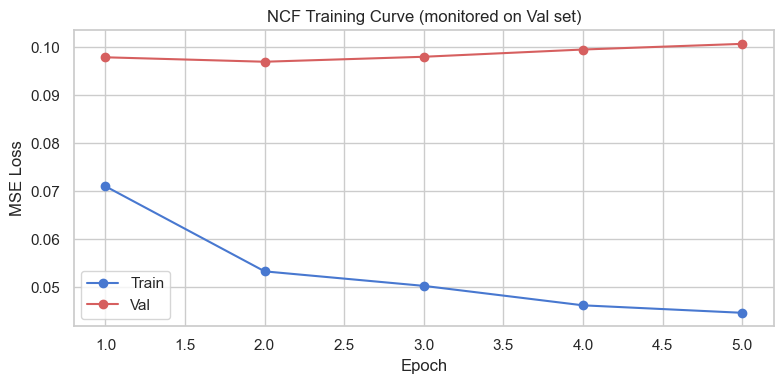

In [15]:
# Training curve
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(train_losses)+1), train_losses, 'b-o', label='Train')
plt.plot(range(1, len(val_losses)+1), val_losses,   'r-o', label='Val')
plt.title('NCF Training Curve (monitored on Val set)')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.legend(); plt.tight_layout()
plt.savefig(OUT_DIR + 'ncf_training_curve.png', dpi=150)
plt.show()

=== NCF Model Evaluation ===
Val    RMSE: 1.2352 | MAE: 0.8105
Test   RMSE: 1.2762 | MAE: 0.8427


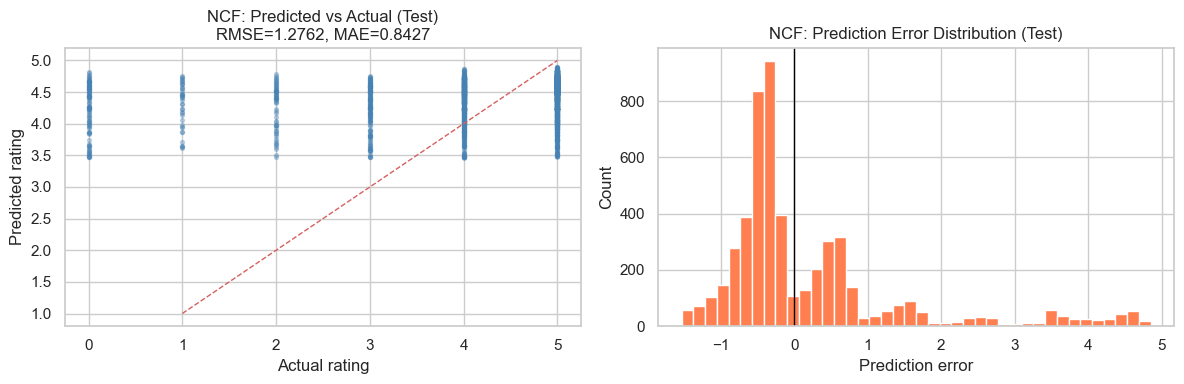

In [16]:
# Final NCF evaluation on TEST set (used only once at the end)
def eval_ncf(loader, name=''):
    model.eval()
    preds_all, labels_all = [], []
    with torch.no_grad():
        for u, r, rating in loader:
            preds_all.extend(model(u.to(DEVICE), r.to(DEVICE)).cpu().numpy())
            labels_all.extend(rating.numpy())
    pred_ratings = np.array(preds_all)  * 4 + 1
    true_ratings = np.array(labels_all) * 4 + 1
    rmse = np.sqrt(np.mean((pred_ratings - true_ratings) ** 2))
    mae  = np.mean(np.abs(pred_ratings - true_ratings))
    print(f'{name:6s} RMSE: {rmse:.4f} | MAE: {mae:.4f}')
    return pred_ratings, true_ratings, rmse, mae

print('=== NCF Model Evaluation ===')
_, _, val_rmse, val_mae   = eval_ncf(val_loader,  'Val')
pred_r, true_r, test_rmse, test_mae = eval_ncf(test_loader, 'Test')

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sample_idx = np.random.choice(len(pred_r), min(2000, len(pred_r)), replace=False)
axes[0].scatter(true_r[sample_idx], pred_r[sample_idx], alpha=0.3, s=8, color='steelblue')
axes[0].plot([1, 5], [1, 5], 'r--', linewidth=1)
axes[0].set_xlabel('Actual rating'); axes[0].set_ylabel('Predicted rating')
axes[0].set_title(f'NCF: Predicted vs Actual (Test)\nRMSE={test_rmse:.4f}, MAE={test_mae:.4f}')

errors = pred_r - true_r
axes[1].hist(errors, bins=40, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_xlabel('Prediction error'); axes[1].set_ylabel('Count')
axes[1].set_title('NCF: Prediction Error Distribution (Test)')

plt.tight_layout()
plt.savefig(OUT_DIR + 'ncf_evaluation.png', dpi=150)
plt.show()

In [17]:
def ncf_score(user_id: int, recipe_id: int) -> float:
    """Return predicted rating score in [0,1]. Returns 0.5 as cold-start fallback."""
    if user_id not in user2idx or recipe_id not in recipe2idx:
        return 0.5
    model.eval()
    with torch.no_grad():
        u = torch.tensor([user2idx[user_id]], dtype=torch.long).to(DEVICE)
        r = torch.tensor([recipe2idx[recipe_id]], dtype=torch.long).to(DEVICE)
        return float(model(u, r).cpu())

# Quick test
sample_uid = int(train_df['user_id'].iloc[0])
sample_rid = int(train_df['recipe_id'].iloc[0])
print(f'NCF score for user={sample_uid}, recipe={sample_rid}: {ncf_score(sample_uid, sample_rid):.4f}')
print('(0 = predicted dislike, 1 = predicted love)')

NCF score for user=2046, recipe=4684: 0.9580
(0 = predicted dislike, 1 = predicted love)


---
# Part 4 -- RAG Pipeline

**Architecture (ingredient-first + ChromaDB re-scoring):**

```
pantry + profile
    ↓
expand_pantry_with_subs()   -- add substitutable ingredients
    ↓
get_cookable_recipes()      -- sparse matrix: top K*5 by overlap
    ↓
ChromaDB collection.get()   -- fetch embeddings for top K
    ↓
SBERT similarity scoring    -- semantic match with profile-aware query
    ↓
Hybrid scoring (6 components):
  0.20 x SBERT + 0.40 x overlap + 0.22 x profile
  + 0.08 x NCF + 0.08 x rating + 0.02 x cluster
    ↓
Cook Now: filter must_buy==0 → top 3
```

Key design decisions:
- ingredient index guarantees high-overlap candidates before SBERT scoring
- expanded pantry includes substitutable ingredients (e.g. salt can sub for garlic)
- ChromaDB provides pre-computed embeddings (faster than on-the-fly SBERT encode)
- profile_alignment hard constraint: avoids_meat recipes score 0.0 for meat-avoiding users

In [18]:
# Load all resources
sbert      = SentenceTransformer(SBERT_MODEL)
chroma     = chromadb.PersistentClient(path=CHROMA_DIR)
collection = chroma.get_collection('recipes')
recipe_df  = pd.read_csv(OUT_DIR + 'recipe_clean.csv')
profile_df = pd.read_csv(OUT_DIR + 'user_profile_enriched.csv')

with open(OUT_DIR + 'substitution.json') as f:
    SUB_DB = json.load(f)

# Load ingr_map for ingredient normalization
try:
    import pickle
    with open(DATA_DIR + 'ingr_map_clean.pkl', 'rb') as f:
        ingr_map = pickle.load(f)
    print(f'ingr_map loaded: {len(ingr_map):,} entries')
except FileNotFoundError:
    ingr_map = {}
    print('ingr_map_clean.pkl not found — using exact match fallback')

RECIPE_LOOKUP = {}
for _, row in recipe_df.iterrows():
    RECIPE_LOOKUP[row['id']] = row.to_dict()
print(f'ChromaDB: {collection.count():,} recipes')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ingr_map loaded: 7 entries
ChromaDB: 225,044 recipes


In [19]:
# ── Ingredient normalization ───────────────────────────────────────────────────
def normalize_ingredient(ingr):
    """Map ingredient variant to canonical form using ingr_map.
    e.g. 'chicken wing' -> 'chicken', 'rice wine' stays 'rice wine'
    """
    key = ingr.strip().lower()
    return ingr_map.get(key, key)

def normalize_pantry(pantry):
    return [normalize_ingredient(i) for i in pantry]


# ── Core helper functions ─────────────────────────────────────────────────────
def get_cluster_fallback(cluster_id):
    """Return average profile of users in the same cluster as cold-start fallback."""
    cluster_users = profiles[profiles['cluster'] == cluster_id]
    if cluster_users.empty:
        return {}
    spicy_mode = cluster_users['spicy_preference'].mode()
    return {
        'avg_minutes':      cluster_users['avg_minutes'].mean(),
        'avg_calories':     cluster_users['avg_calories'].mean(),
        'vegetarian_ratio': cluster_users['vegetarian_ratio'].mean(),
        'spicy_preference': spicy_mode.iloc[0] if not spicy_mode.empty else 'medium',
        'avoids_meat':      cluster_users['vegetarian_ratio'].mean() > 0.7,
        'preferred_cuisine': '[]',
    }

def get_user_profile(user_id):
    row = profile_df[profile_df['user_id'] == user_id]
    if row.empty:
        return None
    profile = row.iloc[0].to_dict()
    # Cold-start fallback: use cluster average for low-confidence users
    if profile.get('low_confidence'):
        cluster_id = profile.get('cluster')
        if cluster_id is not None:
            fallback = get_cluster_fallback(cluster_id)
            for k, v in fallback.items():
                if k not in profile or profile[k] in [None, '[]', 'medium', False]:
                    profile[k] = v
    return profile

def ingredient_overlap(pantry, recipe_ingredients_str):
    """Fraction of recipe ingredients the user already has.
    Uses normalized ingredient names to prevent false matches
    (e.g. 'rice' does not match 'rice wine').
    """
    pantry_norm = set(normalize_pantry(pantry))
    recipe_list = [
        normalize_ingredient(i.strip())
        for i in recipe_ingredients_str.split(',')
        if i.strip() and len(i.strip()) > 3
    ]
    if not recipe_list:
        return 0.0
    matched = sum(1 for r in recipe_list if r in pantry_norm)
    return matched / len(recipe_list)


def profile_alignment(profile, meta):
    """Score 0-1 how well a recipe aligns with user dietary preferences."""
    if not profile:
        return 0.5
    ingr_lower = meta.get('ingredients_str', '').lower()
    meat_kw    = ['beef','pork','chicken','lamb','turkey','bacon','salmon','tuna','shrimp']
    if profile.get('avoids_meat') and any(m in ingr_lower for m in meat_kw):
        return 0.0
    if profile.get('avoids_vegetables') and meta.get('is_vegetarian'):
        return 0.0
    scores = []
    recipe_spicy = bool(meta.get('is_spicy'))
    spicy_want   = profile.get('spicy_preference', 'medium') == 'high'
    scores.append(1.0 if recipe_spicy == spicy_want else 0.4)
    try:
        cuisines = json.loads(profile.get('preferred_cuisine', '[]'))
    except:
        cuisines = []
    tags_lower = str(meta.get('tags_str') or '').lower()
    scores.append(1.0 if any(c.lower() in tags_lower for c in cuisines) else 0.5)
    avg_min = profile.get('avg_minutes', 30)
    rec_min = meta.get('minutes', 30)
    scores.append(max(0.0, 1.0 - abs(rec_min - avg_min) / max(avg_min, 1)))
    return float(np.mean(scores))


def hybrid_score(embed_sim, overlap, p_align, ncf, norm_rating,
                 w=(0.30, 0.25, 0.25, 0.10, 0.10)):
    """
    Weighted combination of 5 signals:
    w0 = SBERT semantic similarity
    w1 = ingredient overlap (pantry utilization)
    w2 = profile alignment (dietary/cuisine/spicy)
    w3 = NCF predicted rating (collaborative NN)
    w4 = avg global rating (popularity)
    """
    return w[0]*embed_sim + w[1]*overlap + w[2]*p_align + w[3]*ncf + w[4]*norm_rating


def find_substitutes(missing):
    result = {}
    for ingr in missing:
        key = ingr.strip().lower()
        if key in SUB_DB:
            subs = SUB_DB[key]
            result[ingr] = subs if isinstance(subs, list) else subs.get('substitutes', [])
        else:
            for k, v in SUB_DB.items():
                if k in key or key in k:
                    result[ingr] = v if isinstance(v, list) else v.get('substitutes', [])
                    break
    return result


def compute_missing_and_subs(pantry, recipe_ingredients_str):
    """
    Returns:
      substitutable: {missing_ingr: substitute_from_pantry}  (user already has a substitute)
      must_buy: [{ingredient, or_buy}]  (must purchase, optionally with a cheaper alternative)
    Uses normalized ingredient names to prevent false matches.
    """
    pantry_norm = set(normalize_pantry(pantry))
    recipe_ingr = [
        i.strip() for i in recipe_ingredients_str.split(',')
        if i.strip() and len(i.strip()) > 3
        and not i.strip().lower().startswith('juice of')
    ]
    missing_all = [
        i for i in recipe_ingr
        if normalize_ingredient(i) not in pantry_norm
    ]
    sub_lookup   = find_substitutes(missing_all)
    substitutable = {}
    must_buy      = []

    for ingr in missing_all:
        options = sub_lookup.get(ingr, [])
        found   = None
        for opt in options:
            # Check if the substitute itself is in pantry (normalized)
            if normalize_ingredient(opt) in pantry_norm:
                found = opt
                break
        if found:
            substitutable[ingr] = found
        else:
            must_buy.append({'ingredient': ingr, 'or_buy': options[0] if options else None})

    return substitutable, must_buy, sub_lookup


def format_steps(steps_str):
    """Convert steps string to numbered markdown list."""
    if not steps_str or str(steps_str) == 'nan':
        return 'Steps not available.'
    steps = [s.strip() for s in steps_str.split('.') if len(s.strip()) > 10]
    return '\n'.join(f'{i+1}. {s}.' for i, s in enumerate(steps[:15]))


print('Helper functions ready.')

Helper functions ready.


=== K-Means Cluster Summary ===
 cluster  n_users  avg_minutes  avg_calories  avg_protein  vegetarian_ratio  avg_rating
       0   129279     18578.69        427.88        37.26              0.03        4.97
       1    23935     30026.58        425.63        38.03              0.03        4.11
       2    21300      2178.31        303.74        16.33              0.93        4.82
       3     5772       305.91       3008.55       128.72              0.15        4.88
       4       24       166.23      36765.12      5557.90              0.02        4.92


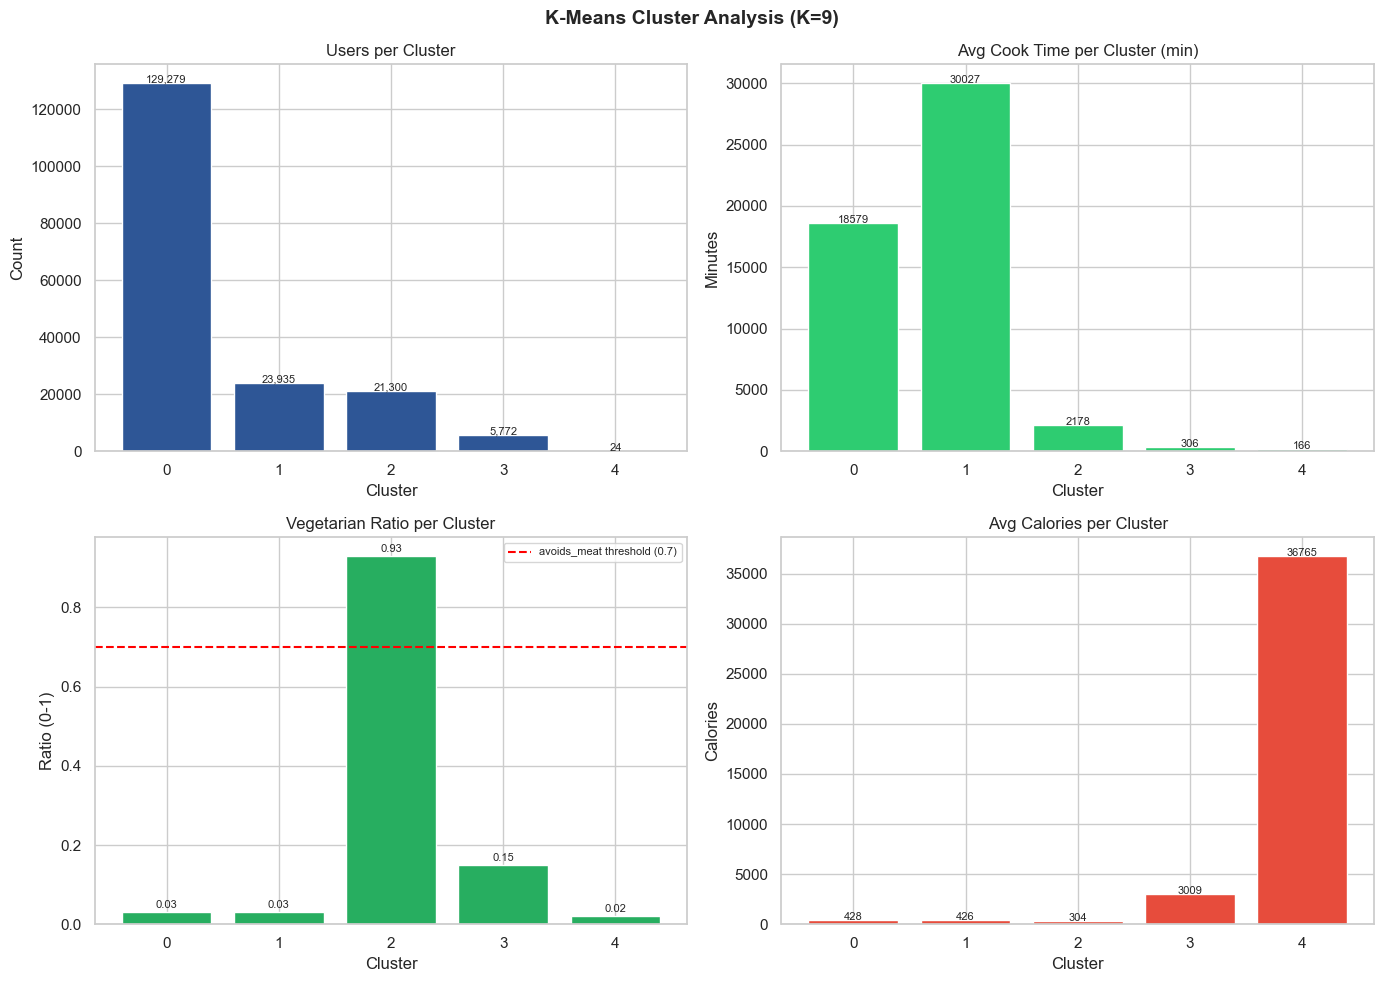

Saved → kmeans_cluster_summary.png


In [20]:
# ── K-Means Cluster Summary ──────────────────────────────────────────────────
cluster_summary = profile_df.groupby('cluster').agg(
    n_users         = ('user_id',         'count'),
    avg_minutes     = ('avg_minutes',      'mean'),
    avg_calories    = ('avg_calories',     'mean'),
    avg_protein     = ('avg_protein_pdv',  'mean'),
    vegetarian_ratio= ('vegetarian_ratio', 'mean'),
    avg_rating      = ('avg_rating_given', 'mean'),
).round(2).reset_index()

print('=== K-Means Cluster Summary ===')
print(cluster_summary.to_string(index=False))

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('K-Means Cluster Analysis (K=9)', fontsize=14, fontweight='bold')

# 1. Users per cluster
axes[0,0].bar(cluster_summary['cluster'], cluster_summary['n_users'],
              color='#2E5696', edgecolor='white')
axes[0,0].set_title('Users per Cluster')
axes[0,0].set_xlabel('Cluster')
axes[0,0].set_ylabel('Count')
for i, v in enumerate(cluster_summary['n_users']):
    axes[0,0].text(i, v + 200, f'{v:,}', ha='center', fontsize=8)

# 2. Avg cook time per cluster
axes[0,1].bar(cluster_summary['cluster'], cluster_summary['avg_minutes'],
              color='#2ECC71', edgecolor='white')
axes[0,1].set_title('Avg Cook Time per Cluster (min)')
axes[0,1].set_xlabel('Cluster')
axes[0,1].set_ylabel('Minutes')
for i, v in enumerate(cluster_summary['avg_minutes']):
    axes[0,1].text(i, v + 1, f'{v:.0f}', ha='center', fontsize=8)

# 3. Vegetarian ratio per cluster
axes[1,0].bar(cluster_summary['cluster'], cluster_summary['vegetarian_ratio'],
              color='#27AE60', edgecolor='white')
axes[1,0].set_title('Vegetarian Ratio per Cluster')
axes[1,0].set_xlabel('Cluster')
axes[1,0].set_ylabel('Ratio (0-1)')
axes[1,0].axhline(y=0.7, color='red', linestyle='--', label='avoids_meat threshold (0.7)')
axes[1,0].legend(fontsize=8)
for i, v in enumerate(cluster_summary['vegetarian_ratio']):
    axes[1,0].text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=8)

# 4. Avg calories per cluster
axes[1,1].bar(cluster_summary['cluster'], cluster_summary['avg_calories'],
              color='#E74C3C', edgecolor='white')
axes[1,1].set_title('Avg Calories per Cluster')
axes[1,1].set_xlabel('Cluster')
axes[1,1].set_ylabel('Calories')
for i, v in enumerate(cluster_summary['avg_calories']):
    axes[1,1].text(i, v + 5, f'{v:.0f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR + 'kmeans_cluster_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → kmeans_cluster_summary.png')

In [21]:
# Build ingredient vocabulary from all recipes
all_ingr_set = set()
for rec in RECIPE_LOOKUP.values():
    for i in rec.get('ingredients_str', '').split(','):
        norm = normalize_ingredient(i.strip())
        if norm:
            all_ingr_set.add(norm)

ingr_vocab      = {ingr: idx for idx, ingr in enumerate(sorted(all_ingr_set))}
recipe_ids_list = list(RECIPE_LOOKUP.keys())

# Build binary recipe x ingredient matrix
recipe_matrix = sp.lil_matrix((len(recipe_ids_list), len(ingr_vocab)), dtype=np.float32)
for row_idx, rid in enumerate(recipe_ids_list):
    rec = RECIPE_LOOKUP[rid]
    for i in rec.get('ingredients_str', '').split(','):
        norm = normalize_ingredient(i.strip())
        if norm in ingr_vocab:
            recipe_matrix[row_idx, ingr_vocab[norm]] = 1

recipe_matrix = recipe_matrix.tocsr()
print(f'Ingredient index built: {recipe_matrix.shape}')

def expand_pantry_with_subs(pantry):
    """ขยาย pantry โดยเพิ่ม ingredients ที่ pantry สามารถ substitute ได้"""
    pantry_norm = set(normalize_pantry(pantry))
    expanded    = set(pantry_norm)
    for ingr in pantry_norm:
        for target, subs in SUB_DB.items():
            sub_list = subs if isinstance(subs, list) else subs.get('substitutes', [])
            if ingr in [normalize_ingredient(s) for s in sub_list]:
                expanded.add(normalize_ingredient(target))
    return list(expanded)


def get_cookable_recipes(pantry, top_n=300):
    """Return top_n recipes ranked by ingredient overlap with pantry + substitutes."""
    expanded_pantry = expand_pantry_with_subs(pantry)
    pantry_vec = np.zeros(len(ingr_vocab), dtype=np.float32)
    for i in expanded_pantry:
        norm = normalize_ingredient(i.strip())
        if norm in ingr_vocab:
            pantry_vec[ingr_vocab[norm]] = 1

    scores      = recipe_matrix.dot(pantry_vec)
    n_ingr      = np.array(recipe_matrix.sum(axis=1)).flatten()
    overlap_pct = np.divide(scores, n_ingr, where=n_ingr > 0, out=np.zeros_like(scores))

    top_idx = np.argsort(overlap_pct)[::-1][:top_n]
    return [(recipe_ids_list[i], float(overlap_pct[i])) for i in top_idx if overlap_pct[i] > 0]

print('get_cookable_recipes() ready.')

Ingredient index built: (225044, 14675)
get_cookable_recipes() ready.


In [22]:
def recommend(user_id, pantry, top_k=20, return_top_n=3,
              weights=(0.20, 0.40, 0.22, 0.08, 0.08, 0.02)):
    """Retrieve and rank recipes using hybrid scoring.

    Strategy:
    1. ingredient index (sparse matrix) finds top_k*5 recipes by overlap
    2. ChromaDB re-scores top_k of those by semantic similarity
    3. Hybrid score (6 components) produces final ranking

    Weights: SBERT(0.20), overlap(0.40), profile(0.22), NCF(0.08), rating(0.08), cluster(0.02)
    """
    user_profile = get_user_profile(user_id)

    # Build query text from pantry + full profile for SBERT scoring
    cuisine     = user_profile.get('preferred_cuisine', '[]') if user_profile else '[]'
    spicy       = user_profile.get('spicy_preference', 'medium') if user_profile else 'medium'
    sweet       = user_profile.get('sweet_preference', 'medium') if user_profile else 'medium'
    avoids_meat = user_profile.get('avoids_meat', False) if user_profile else False
    diet_flags  = user_profile.get('dietary_flags', '[]') if user_profile else '[]'
    avg_min     = user_profile.get('avg_minutes', 30) if user_profile else 30
    veg_ratio   = user_profile.get('vegetarian_ratio', 0) if user_profile else 0
    diet_hint   = 'vegetarian' if (veg_ratio > 0.7 or avoids_meat) else 'any'
    time_hint   = 'quick under 30 minutes' if avg_min < 30 else 'regular'
    query_text  = (
        f"simple recipe using only: {', '.join(pantry[:10])}. "
        f"cuisine: {cuisine}. spicy: {spicy}. sweet: {sweet}. "
        f"diet: {diet_hint}. dietary flags: {diet_flags}. cook time: {time_hint}."
    )

    # Step 1: ingredient index — find top recipes by overlap (fast, exact)
    cookable = get_cookable_recipes(pantry, top_n=top_k * 5)[:top_k]
    if not cookable:
        return []

    # Step 2: ChromaDB re-score — get semantic similarity for top cookable recipes
    # Query ChromaDB with profile-aware query text
    q_embed = sbert.encode([query_text], normalize_embeddings=True)
    cookable_ids = [str(rid) for rid, _ in cookable]
    try:
        chroma_results = collection.get(
            ids=cookable_ids,
            include=['embeddings', 'metadatas']
        )
        # Build id -> (embedding, metadata) map
        id_to_emb  = {cid: emb for cid, emb in zip(chroma_results['ids'], chroma_results['embeddings'])}
        id_to_meta = {cid: meta for cid, meta in zip(chroma_results['ids'], chroma_results['metadatas'])}
    except Exception:
        id_to_emb  = {}
        id_to_meta = {}

    # Step 3: hybrid scoring
    candidates = []
    for recipe_id, overlap in cookable:
        rid_str = str(recipe_id)
        rec     = RECIPE_LOOKUP.get(recipe_id, {})

        # Get metadata — prefer ChromaDB (has computed fields), fallback to RECIPE_LOOKUP
        if rid_str in id_to_meta:
            meta = id_to_meta[rid_str]
        else:
            meta = {
                'name':            rec.get('name', ''),
                'minutes':         rec.get('minutes', 0),
                'calories':        rec.get('calories', 0.0),
                'ingredients_str': rec.get('ingredients_str', ''),
                'tags_str':        rec.get('tags_str', ''),
                'is_vegetarian':   rec.get('is_vegetarian', False),
                'is_vegan':        rec.get('is_vegan', False),
                'is_spicy':        rec.get('is_spicy', False),
                'difficulty':      rec.get('difficulty', 'medium'),
                'n_steps':         rec.get('n_steps', 0),
            }

        # SBERT similarity — use ChromaDB embedding if available, else encode on-the-fly
        if rid_str in id_to_emb:
            rec_emb   = np.array(id_to_emb[rid_str])
            embed_sim = float(np.dot(q_embed[0], rec_emb / (np.linalg.norm(rec_emb) + 1e-9)))
        else:
            rec_text  = rec.get('ingredients_str', '')
            rec_emb   = sbert.encode([rec_text], normalize_embeddings=True)[0]
            embed_sim = float(np.dot(q_embed[0], rec_emb))

        p_align = profile_alignment(user_profile, meta)
        if p_align == 0.0:
            continue

        ncf_s      = ncf_score(user_id, recipe_id)
        avg_rating = avg_rating_cache.get(recipe_id, np.nan)
        norm_r     = (avg_rating - 1) / 4 if not np.isnan(avg_rating) else 0.5

        cluster_id    = int(user_profile.get('cluster', -1)) if user_profile else -1
        cluster_score = 0.5
        if cluster_id >= 0:
            c_users = profiles[profiles['cluster'] == cluster_id]
            c_veg   = c_users['vegetarian_ratio'].mean() if len(c_users) > 0 else 0.5
            is_veg  = meta.get('is_vegetarian', False)
            cluster_score = 1.0 if (c_veg > 0.7 and is_veg) or (c_veg <= 0.7 and not is_veg) else 0.3

        w_sbert, w_over, w_prof, w_ncf, w_rat, w_clust = weights
        score = (w_sbert * embed_sim + w_over * overlap + w_prof * p_align +
                 w_ncf * ncf_s + w_rat * norm_r + w_clust * cluster_score)

        candidates.append({
            'recipe_id':       recipe_id,
            'name':            meta.get('name', ''),
            'minutes':         meta.get('minutes', 0),
            'calories':        meta.get('calories', 0),
            'ingredients_str': meta.get('ingredients_str', ''),
            'tags_str':        str(meta.get('tags_str') or ''),
            'steps':           rec.get('steps_str', ''),
            'embed_sim':       round(embed_sim, 3),
            'overlap':         round(overlap, 3),
            'profile_align':   round(p_align, 3),
            'ncf_score':       round(ncf_s, 3),
            'final_score':     round(score, 4),
        })

    return sorted(candidates, key=lambda x: x['final_score'], reverse=True)[:return_top_n]

print('recommend() ready.')

recommend() ready.


In [23]:
def call_ollama(prompt, temperature=0.3):
    try:
        r = requests.post(OLLAMA_URL,
                          json={'model': OLLAMA_MODEL, 'prompt': prompt,
                                'stream': False, 'options': {'temperature': temperature}},
                          timeout=120)
        return r.json().get('response', '').strip()
    except Exception as e:
        return f'[LLM unavailable: {e}]'


COOK_NOW_PROMPT = """You are Fridge Hero. Recommend this recipe based ONLY on the context below.
User pantry: {pantry}
User preference: {profile_summary}
Recipe: {name}
Ingredients: {ingredients}

## Substitutions Applied
{substitutable}

Write 2-3 sentences: (1) why this recipe suits this user, (2) explicitly mention each substitution
being applied using the format 'use X instead of Y'. Be friendly and concise."""


def generate_cook_now(user_id, pantry, top_k=50):
    """Track A: up to 3 recipes cookable now — no shopping required.
    All missing ingredients must be substitutable from pantry.
    Falls back to best overlap recipes if fewer than 3 fully cookable.
    """
    profile  = get_user_profile(user_id)
    all_recs = recommend(user_id, pantry, top_k=top_k, return_top_n=top_k)
    profile_summary = (
        f"cuisine: {profile.get('preferred_cuisine','?')}, "
        f"spicy: {profile.get('spicy_preference','?')}"
    ) if profile else 'No profile'

    results = []
    for rec in all_recs:
        substitutable, must_buy, _ = compute_missing_and_subs(pantry, rec['ingredients_str'])
        if len(must_buy) == 0:
            sub_text = ', '.join(f"{k} -> use {v}" for k, v in substitutable.items()) \
                       if substitutable else 'All ingredients available'
            llm_intro = call_ollama(COOK_NOW_PROMPT.format(
                pantry=', '.join(pantry[:8]),
                profile_summary=profile_summary,
                name=rec['name'],
                ingredients=rec['ingredients_str'][:300],
                substitutable=sub_text
            ))
            results.append({**rec, '_pantry': pantry,
                            'substitutable': substitutable,
                            'must_buy': [], 'llm_intro': llm_intro})
            if len(results) == 3:
                break

    # Fallback: best overlap recipes if fewer than 3 fully cookable
    # if len(results) < 3:
    #     for rec in sorted(all_recs, key=lambda x: x['overlap'], reverse=True):
    #         if any(r['recipe_id'] == rec['recipe_id'] for r in results):
    #             continue
    #         substitutable, must_buy, _ = compute_missing_and_subs(pantry, rec['ingredients_str'])
    #         sub_text = ', '.join(f"{k} -> use {v}" for k, v in substitutable.items()) \
    #                    if substitutable else 'All ingredients available'
    #         llm_intro = call_ollama(COOK_NOW_PROMPT.format(
    #             pantry=', '.join(pantry[:8]),
    #             profile_summary=profile_summary,
    #             name=rec['name'],
    #             ingredients=rec['ingredients_str'][:300],
    #             substitutable=sub_text
    #         ))
    #         results.append({**rec, '_pantry': pantry,
    #                         'substitutable': substitutable,
    #                         'must_buy': must_buy, 'llm_intro': llm_intro})
    #         if len(results) == 3:
    #             break
    return results


print('Generate functions ready.')

Generate functions ready.


In [24]:
# Smoke test
test_uid    = int(profile_df[~profile_df['low_confidence']]['user_id'].iloc[0])
test_pantry = ['chicken breast', 'garlic', 'onion', 'soy sauce', 'ginger', 'rice']

# Pre-compute avg rating cache
avg_rating_cache = train_df.groupby('recipe_id')['rating'].mean().to_dict()


print('=== Cook Now ===')
cook_now = generate_cook_now(test_uid, test_pantry)
for i, r in enumerate(cook_now):
    print(f"{i+1}. {r['name']} | overlap: {r['overlap']} | must_buy: {r['must_buy']}")


=== Cook Now ===
1. ginger and scallion sauce | overlap: 0.75 | must_buy: []
2. grpa s best homemade turkey gravy | overlap: 0.667 | must_buy: []


---
# Part 5 -- Evaluation

Three evaluation levels:
1. **NCF model performance** -- RMSE/MAE on official val and test sets
2. **Pantry utilisation** -- computed after substitution and must_buy==0 filter (should approach 1.0)
3. **LLM-as-judge** -- faithfulness, relevance, helpfulness, overall (50 profiled users from NB1)
4. **RAGAS** -- standardised RAG evaluation (faithfulness, answer_relevancy, context_precision)

Design decisions:
- pantry_util measured on cook_now output (post-filter) not raw recommend() output
- LLM judge uses all 50 users from eval_user_ids.csv (guaranteed real LLM profiles from NB1)
- Test set touched only once for NCF final reporting

In [25]:
JUDGE_PROMPT = """You are a strict evaluation judge for a recipe recommendation system.
Score the response on three dimensions. Return ONLY valid JSON, no explanation.

User request: {user_request}
User profile: {profile_summary}
Retrieved recipe (ground truth): {recipe_context}
System response: {response}

Return:
{{"faithfulness": 1-5, "faithfulness_reason": "...",
  "relevance": 1-5,     "relevance_reason": "...",
  "helpfulness": 1-5,   "helpfulness_reason": "...",
  "overall": 1-5}}

Faithfulness (1-5): response only uses info from retrieved recipe, no hallucination
Relevance (1-5): matches user request and dietary preferences
Helpfulness (1-5): actionable — has clear steps and substitution info"""


def llm_judge(result, user_request, profile):
    """Evaluate one recommendation result using LLM as judge."""
    profile_summary = (
        f"cuisine: {profile.get('preferred_cuisine','?')}, "
        f"spicy: {profile.get('spicy_preference','?')}"
    ) if profile else 'unknown'
    recipe  = result['recipe']
    context = f"{recipe['name']}: {recipe['ingredients_str'][:300]}"
    raw = call_ollama(JUDGE_PROMPT.format(
        user_request    = user_request,
        profile_summary = profile_summary,
        recipe_context  = context,
        response        = result['llm_response'][:1000]
    ), temperature=0.0)
    try:
        return json.loads(re.sub(r'```[\w]*', '', raw).strip())
    except:
        return {'faithfulness': None, 'relevance': None, 'helpfulness': None, 'overall': None}


print('LLM-as-judge ready.')

LLM-as-judge ready.


In [26]:
# ── Evaluation — Retrieval Quality + LLM Judge ─────────────────────────────
# pantry_util is computed AFTER substitution and AFTER filtering must_buy==0

# Load eval user IDs exported by NB1 (50 users with real LLM profiles)
eval_user_ids_path = OUT_DIR + 'eval_user_ids.csv'
if os.path.exists(eval_user_ids_path):
    llm_eval_ids = set(pd.read_csv(eval_user_ids_path)['user_id'].tolist())
    print(f'Loaded {len(llm_eval_ids)} eval user IDs from NB1')
else:
    llm_eval_ids = set()
    print('eval_user_ids.csv not found — LLM judge will be skipped')


# Load test set and build eval pool
test_raw      = pd.read_csv(DATA_DIR + 'interactions_test.csv')
eval_pool     = test_raw[test_raw['rating'] >= 4].drop_duplicates(subset='user_id')
priority_pool = eval_pool[eval_pool['user_id'].isin(llm_eval_ids)]
other_pool    = eval_pool[~eval_pool['user_id'].isin(llm_eval_ids)]
n_priority    = len(priority_pool)
EVAL_SAMPLE   = 50
n_other       = max(0, EVAL_SAMPLE + 10 - n_priority)

eval_users_raw = pd.concat([
    priority_pool,
    other_pool.sample(min(n_other, len(other_pool)), random_state=42)
]).reset_index(drop=True)

# Filter invalid users (no train interactions or recipe not in RECIPE_LOOKUP)
def build_pantry(uid):
    prev = train_df[
        (train_df['user_id'] == uid) & (train_df['rating'] >= 4)
    ].tail(5)['recipe_id'].tolist()
    pantry = []
    for rid in prev:
        r = RECIPE_LOOKUP.get(rid, {})
        if r:
            pantry.extend(r.get('ingredients_str', '').split(',')[:5])  # 5 per recipe
    return list(set(pantry))[:20]  # cap at 20

valid_rows = []
for _, row in eval_users_raw.iterrows():
    if build_pantry(int(row['user_id'])):
        valid_rows.append(row)
    if len(valid_rows) == EVAL_SAMPLE:
        break

eval_users = pd.DataFrame(valid_rows).reset_index(drop=True)
print(f'Eval users: {len(eval_users)} (priority with LLM profile: {n_priority})')

retrieval_records = []
judge_records     = []

for _, row in tqdm(eval_users.iterrows(), total=len(eval_users), desc='Evaluating'):
    uid         = int(row['user_id'])
    true_recipe = int(row['recipe_id'])
    profile     = get_user_profile(uid)
    if not profile:
        continue

    sim_pantry = build_pantry(uid)
    if not sim_pantry:
        continue

    cook_now = generate_cook_now(uid, sim_pantry, top_k=50)
    if not cook_now:
        continue

    top_rec = cook_now[0]
    rec_ids = [r['recipe_id'] for r in cook_now]

    # pantry_util after substitution + must_buy==0 filter
    pantry_norm  = set(normalize_pantry(sim_pantry))
    sub_keys     = set(normalize_ingredient(k) for k in top_rec.get('substitutable', {}).keys())
    all_covered  = pantry_norm | sub_keys
    recipe_ingrs = [
        normalize_ingredient(i.strip())
        for i in top_rec.get('ingredients_str', '').split(',')
        if i.strip() and len(i.strip()) > 3
    ]
    pantry_util = (
        sum(1 for i in recipe_ingrs if i in all_covered) / len(recipe_ingrs)
        if recipe_ingrs else 0
    )

    retrieval_records.append({
        'user_id':      uid,
        'pantry_util':  pantry_util,
        'n_cook_now':   len(cook_now),
        'question':     f"What should I cook with {', '.join(sim_pantry[:5])}?",
        'answer': (
            f"You should make {top_rec['name']}. "
            f"It uses: {top_rec.get('ingredients_str','')[:200]}"
        ),
'contexts': [top_rec.get('ingredients_str','') + ' ' + str(top_rec.get('steps') or '')[:200]],        'ground_truth': (
            RECIPE_LOOKUP.get(rec_ids[0], {}).get('name', '') + ': ' +
            RECIPE_LOOKUP.get(rec_ids[0], {}).get('ingredients_str', '')[:150]
        ),
    })

    # LLM judge — only users with real LLM profiles
    if uid in llm_eval_ids:
        try:
            eval_result = {'recipe': top_rec, 'llm_response': top_rec.get('llm_intro', '')}
            judge = llm_judge(eval_result, 'Open recommendation', profile)
            judge_records.append({
                'user_id':      uid,
                'faithfulness': judge.get('faithfulness'),
                'relevance':    judge.get('relevance'),
                'helpfulness':  judge.get('helpfulness'),
                'overall':      judge.get('overall'),
            })
        except Exception as e:
            print(f'Judge failed for user {uid}: {e}')
            continue

retrieval_df = pd.DataFrame(retrieval_records)
judge_df     = pd.DataFrame(judge_records) if judge_records else pd.DataFrame(
    columns=['user_id','faithfulness','relevance','helpfulness','overall'])
eval_df = retrieval_df.merge(judge_df, on='user_id', how='left')

print(f'Retrieval evaluated : {len(retrieval_df)} users')
print(f'LLM judge evaluated : {len(judge_df)} users')
print(f'Avg cook_now recipes: {eval_df["n_cook_now"].mean():.2f}')
print(eval_df['n_cook_now'].value_counts().sort_index())

Loaded 50 eval user IDs from NB1
Eval users: 50 (priority with LLM profile: 50)


Evaluating: 100%|██████████| 50/50 [15:13<00:00, 18.27s/it]

Retrieval evaluated : 50 users
LLM judge evaluated : 49 users
Avg cook_now recipes: 2.98
n_cook_now
2     1
3    49
Name: count, dtype: int64


=== Avg cook_now recipes per user ===
Avg cook_now recipes per user: 2.98
n_cook_now
2     1
3    49
Name: count, dtype: int64
=== Pantry Utilisation (after substitution + must_buy==0 filter) ===
Evaluated users  : 50
Pantry util mean : 1.000
Pantry util std  : 0.000
Pantry util min  : 1.000
Pantry util max  : 1.000

=== LLM Judge -- Response Quality ===
faithfulness   : 2.76 / 5  (n=49)
relevance      : 3.37 / 5  (n=49)
helpfulness    : 2.80 / 5  (n=49)
overall        : 2.61 / 5  (n=49)


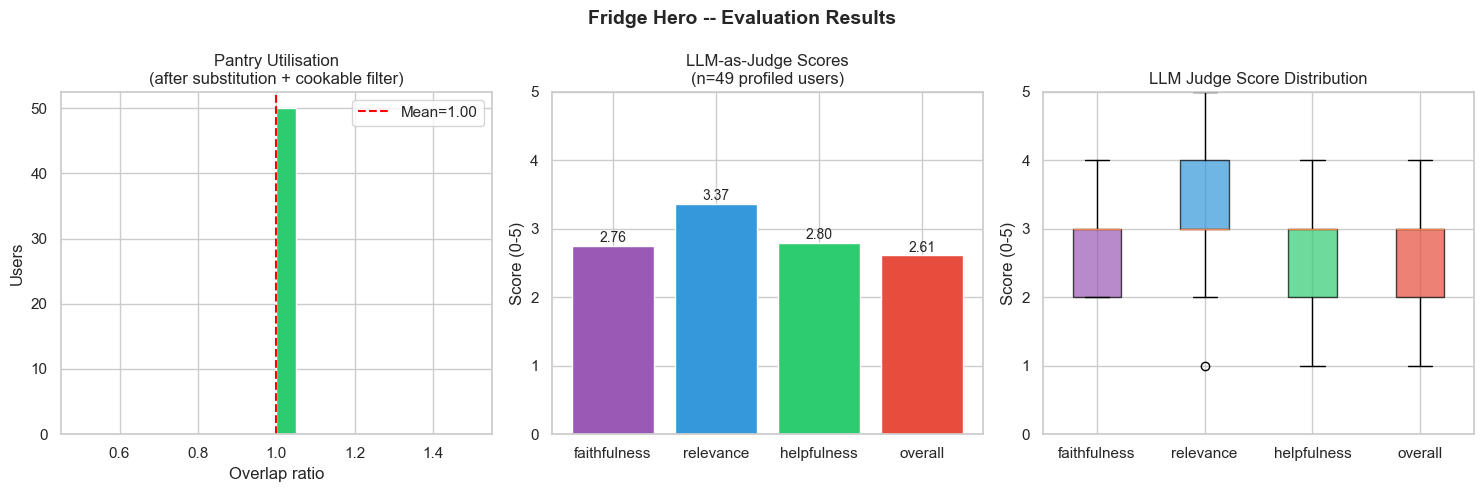

Saved evaluation_full.png


In [27]:
# -- Print evaluation results
print('=== Avg cook_now recipes per user ===')
print(f'Avg cook_now recipes per user: {eval_df["n_cook_now"].mean():.2f}')
print(eval_df['n_cook_now'].value_counts().sort_index())
print('=== Pantry Utilisation (after substitution + must_buy==0 filter) ===')
print(f'Evaluated users  : {len(retrieval_df)}')
print(f'Pantry util mean : {retrieval_df["pantry_util"].mean():.3f}')
print(f'Pantry util std  : {retrieval_df["pantry_util"].std():.3f}')
print(f'Pantry util min  : {retrieval_df["pantry_util"].min():.3f}')
print(f'Pantry util max  : {retrieval_df["pantry_util"].max():.3f}')
print()
print('=== LLM Judge -- Response Quality ===')
for col in ['faithfulness', 'relevance', 'helpfulness', 'overall']:
    n = eval_df[col].notna().sum()
    if n > 0:
        print(f'{col:15s}: {eval_df[col].dropna().mean():.2f} / 5  (n={n})')

eval_df.to_csv(OUT_DIR + 'evaluation_results.csv', index=False)

# -- Visualise
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Fridge Hero -- Evaluation Results', fontsize=14, fontweight='bold')

# 1. Pantry utilisation distribution (after must_buy==0 filter)
axes[0].hist(retrieval_df['pantry_util'], bins=20, color='#2ECC71', edgecolor='white')
axes[0].axvline(retrieval_df['pantry_util'].mean(), color='red', linestyle='--',
                label=f'Mean={retrieval_df["pantry_util"].mean():.2f}')
axes[0].set_title('Pantry Utilisation\n(after substitution + cookable filter)')
axes[0].set_xlabel('Overlap ratio')
axes[0].set_ylabel('Users')
axes[0].legend()

# 2. LLM Judge scores bar chart
judge_cols  = ['faithfulness', 'relevance', 'helpfulness', 'overall']
judge_means = [eval_df[c].dropna().mean() for c in judge_cols]
judge_n     = [eval_df[c].notna().sum() for c in judge_cols]
colors      = ['#9B59B6', '#3498DB', '#2ECC71', '#E74C3C']
bars = axes[1].bar(judge_cols, judge_means, color=colors, edgecolor='white')
axes[1].set_ylim(0, 5)
axes[1].set_title(f'LLM-as-Judge Scores\n(n={judge_n[0]} profiled users)')
axes[1].set_ylabel('Score (0-5)')
for bar, v in zip(bars, judge_means):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.05, f'{v:.2f}', ha='center', fontsize=10)

# 3. LLM Judge boxplot
judge_data = [eval_df[c].dropna().values for c in judge_cols]
bp = axes[2].boxplot(judge_data, labels=judge_cols, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[2].set_ylim(0, 5)
axes[2].set_title('LLM Judge Score Distribution')
axes[2].set_ylabel('Score (0-5)')

plt.tight_layout()
plt.savefig(OUT_DIR + 'evaluation_full.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved evaluation_full.png')

In [28]:
# Save ragas dataset
ragas_data = [
    {k: row[k] for k in ['question','answer','contexts','ground_truth']}
    for _, row in eval_df.iterrows()
    if row.get('question')
]

with open(OUT_DIR + 'ragas_input.json', 'w') as f:
    json.dump(ragas_data, f, indent=2)

print(f'Saved {len(ragas_data)} records to ragas_input.json')

Saved 50 records to ragas_input.json


Loaded 50 records


Evaluating:   0%|          | 0/150 [00:00<?, ?it/s]

{'faithfulness': 0.5722, 'answer_relevancy': 0.6177, 'context_precision': 0.0800}


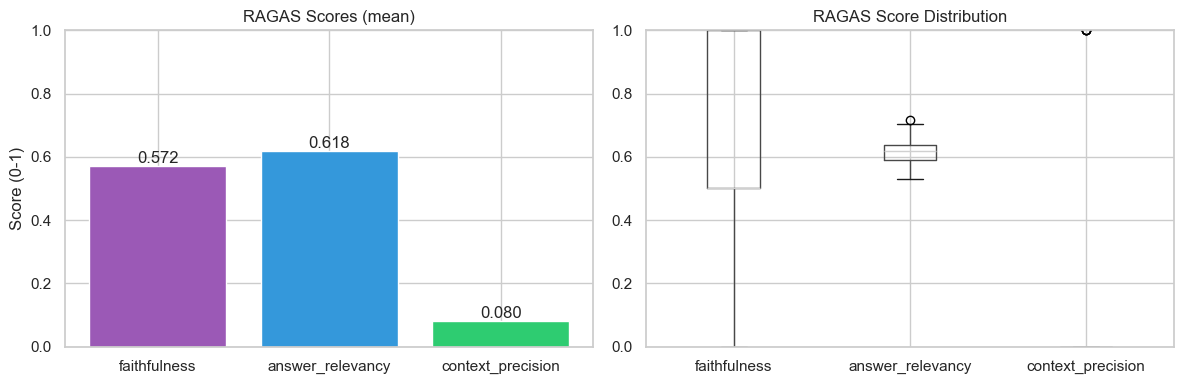

In [29]:
with open(OUT_DIR + 'ragas_input.json') as f:
    ragas_data = json.load(f)
ragas_ds = HFDataset.from_list(ragas_data)
print(f'Loaded {len(ragas_ds)} records')

ollama_llm   = LangchainLLMWrapper(ChatOllama(model=OLLAMA_MODEL, temperature=0, format='json'))
ollama_embed = LangchainEmbeddingsWrapper(OllamaEmbeddings(model='nomic-embed-text'))

faithfulness      = Faithfulness(llm=ollama_llm)
answer_relevancy  = AnswerRelevancy(llm=ollama_llm, embeddings=ollama_embed)
context_precision = ContextPrecision(llm=ollama_llm)

ragas_scores = evaluate(
    ragas_ds,
    metrics=[faithfulness, answer_relevancy, context_precision],
    llm=ollama_llm,
    embeddings=ollama_embed,
    run_config=RunConfig(timeout=180, max_workers=1, max_retries=3)
)
print(ragas_scores)

ragas_df = ragas_scores.to_pandas()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

means = ragas_df[['faithfulness','answer_relevancy','context_precision']].mean()
bars  = axes[0].bar(means.index, means.values, color=['#9B59B6','#3498DB','#2ECC71'])
axes[0].set_ylim(0, 1)
axes[0].set_title('RAGAS Scores (mean)')
axes[0].set_ylabel('Score (0-1)')
for bar, v in zip(bars, means.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.3f}', ha='center')

ragas_df[['faithfulness','answer_relevancy','context_precision']].boxplot(ax=axes[1])
axes[1].set_ylim(0, 1)
axes[1].set_title('RAGAS Score Distribution')

plt.tight_layout()
plt.savefig(OUT_DIR + 'ragas_evaluation.png', dpi=150)
plt.show()

---
# Part 6 -- Gradio Interface

Interactive demo. Input: Customer ID + pantry ingredients.

Two tabs:
- **Customer Profile** -- interaction stats + LLM-inferred preferences + cluster assignment
- **Cook Now (3 recipes)** -- recipes cookable immediately, no shopping required,
  substitutions applied automatically from pantry

In [30]:
def fmt_profile_panel(user_id):
    """Format customer profile for display — raw stats + LLM-inferred fields."""
    profile = get_user_profile(user_id)
    if not profile:
        return '**Customer not found in database.**'

    user_history = train_df[train_df['user_id'] == user_id]
    n_total      = len(user_history)
    n_liked      = len(user_history[user_history['rating'] >= 4])
    last_id      = user_history.sort_values('date').tail(1)['recipe_id'].values
    last_name    = ''
    if len(last_id) > 0:
        r = RECIPE_LOOKUP.get(int(last_id[0]), {})
        last_name = r.get('name', 'Unknown') if r else 'Unknown'

    try:
        cuisines_str = ', '.join(json.loads(profile.get('preferred_cuisine', '[]'))) or 'Not determined'
    except:
        cuisines_str = 'Not determined'
    try:
        flags_str = ', '.join(json.loads(profile.get('dietary_flags', '[]'))) or 'None'
    except:
        flags_str = 'None'

    lines = [
        '## Customer Profile', '',
        '**From interaction history:**',
        f'- Total recipes rated: **{n_total}**',
        f'- Recipes liked (rating >= 4): **{n_liked}**',
        f'- Last recipe cooked: **{last_name}**',
        f'- Avg cook time preferred: **{profile.get("avg_minutes", 0):.0f} min**',
        f'- Avg calories preferred: **{profile.get("avg_calories", 0):.0f} kcal**',
        f'- Vegetarian ratio: **{profile.get("vegetarian_ratio", 0)*100:.0f}%**',
        f'- User cluster: **#{profile.get("cluster", "N/A")}**',
        '',
        '**From AI analysis (LLM-inferred):**',
        f'- Preferred cuisine: **{cuisines_str}**',
        f'- Spicy preference: **{profile.get("spicy_preference", "?")}**',
        f'- Sweet preference: **{profile.get("sweet_preference", "?")}**',
        f'- Avoids meat: **{profile.get("avoids_meat", False)}**',
        f'- Avoids vegetables: **{profile.get("avoids_vegetables", False)}**',
        f'- Dietary flags: **{flags_str}**',
        f'- Profile confidence: **{profile.get("confidence", "low")}**',
    ]
    return '\n'.join(lines)


def fmt_recipe_card(rec, idx, show_steps=True):
    """Format a Cook Now recipe card with ingredient breakdown and steps."""
    lines = []
    lines.append(f'### {idx}. {rec["name"]}')
    lines.append(f'*{rec["minutes"]} min | {rec["calories"]:.0f} kcal | '
                 f'pantry match: {rec["overlap"]*100:.0f}%*')
    lines.append('')
    lines.append(rec.get('llm_intro', ''))
    lines.append('')

    # Show what user has
    pantry_norm = set(normalize_pantry(rec.get('_pantry', [])))
    recipe_ingr = [
        i.strip() for i in rec.get('ingredients_str', '').split(',')
        if i.strip() and len(i.strip()) > 3
    ]
    have = [i for i in recipe_ingr if normalize_ingredient(i) in pantry_norm]
    if have:
        lines.append('**Ingredients you have:**')
        for i in have:
            lines.append(f'- \u2705 {i}')
        lines.append('')

    if rec.get('substitutable'):
        lines.append('**Substitutions (use what you have):**')
        for ingr, sub in rec['substitutable'].items():
            lines.append(f'- \U0001f504 {ingr} \u2192 use **{sub}** instead')
        lines.append('')

    if show_steps:
        lines.append('**How to cook:**')
        lines.append(format_steps(rec.get('steps', '')))
        lines.append('')
    lines.append('---')
    return '\n'.join(lines)


def gradio_recommend(user_id_str, pantry_str):
    """Returns (profile_out, cook_now_out)."""
    try:
        user_id = int(user_id_str.strip())
    except:
        return ('Invalid Customer ID.', '')

    pantry = [p.strip() for p in pantry_str.split(',') if p.strip()]
    if not pantry:
        return ('Please enter at least one ingredient.', '')

    gr.Info('Loading customer profile...')
    profile_out = fmt_profile_panel(user_id)

    gr.Info('Finding recipes you can cook right now...')
    cook_now_recs = generate_cook_now(user_id, pantry)

    cook_now_out = 'No cookable recipes found with current pantry.' if not cook_now_recs else \
        '\n'.join(['## Cook Now -- Recipes you can make today\n',
                   '*All recipes below can be made without buying anything new.*\n'] +
                  [fmt_recipe_card(rec, i+1, show_steps=True) for i, rec in enumerate(cook_now_recs)])

    return (profile_out, cook_now_out)


print('Gradio handler ready.')

Gradio handler ready.


In [31]:
with gr.Blocks(title='Fridge Hero', theme=gr.themes.Soft()) as demo:
    gr.Markdown('# Fridge Hero\n### Zero-waste cooking -- use what you have, waste nothing')

    with gr.Row():
        with gr.Column(scale=1):
            gr.Markdown('### Input')
            user_id_input = gr.Textbox(label='Customer ID', placeholder='e.g. 62086')
            pantry_input  = gr.Textbox(
                label='Ingredients in your fridge (comma-separated)',
                placeholder='e.g. chicken, garlic, onion, soy sauce, ginger, rice',
                lines=4
            )
            submit_btn = gr.Button('Find Recipes I Can Cook Now', variant='primary', size='lg')
            gr.Markdown("""
            **How it works:**
            - Enter your Customer ID and available ingredients
            - Fridge Hero finds 3 recipes you can cook right now with no shopping needed
            - Missing ingredients are substituted from your pantry automatically
            """)
            gr.Examples(
                label='Try these examples',
                examples=[
                    ['62086',  'chicken, garlic, soy sauce, ginger, basil, fish sauce, rice, onion'],
                    ['278113', 'egg, butter, flour, sugar, vanilla, baking powder, milk'],
                    ['842751', 'tofu, miso, dashi, soy sauce, mushroom, green onion'],
                    ['435152', 'beef, onion, garlic, tomato, olive oil'],
                    ['688815', 'spinach, egg, cheese, onion, garlic'],
                ],
                inputs=[user_id_input, pantry_input]
            )

        with gr.Column(scale=2):
            gr.Markdown('### Results')
            with gr.Tab('Customer Profile'):
                profile_output  = gr.Markdown()
            with gr.Tab('Cook Now -- 3 Recipes'):
                gr.Markdown('*Recipes you can cook right now -- no shopping needed*')
                cook_now_output = gr.Markdown()

    submit_btn.click(
        fn=gradio_recommend,
        inputs=[user_id_input, pantry_input],
        outputs=[profile_output, cook_now_output],
        show_progress='full'
    )

print('Gradio app built.')

Gradio app built.


In [32]:

gr.close_all()
demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7861
* Running on public URL: https://780a8ebabb85f835da.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
